In [ ]:
#!/usr/bin/env python3
import matplotlib.pyplot as plt
import numpy as np
import pyvinecopulib as pv
from scipy.stats import norm


def copula_params(family: str, tau: float, nu: int = 4) -> dict[str, float]:
  if family == "clayton":
    return {"theta": 2.0 * tau / (1.0 - tau)}
  if family == "gumbel":
    return {"theta": 1.0 / (1.0 - tau)}
  if family in {"gaussian", "student"}:
    params = {"rho": np.sin(np.pi * tau / 2.0)}
    if family == "student":
      params["nu"] = float(nu)
    return params
  raise ValueError(f"Unknown family: {family}")


def set_bicop(family: str, params: dict[str, float]) -> pv.Bicop:
  if family == "clayton":
    return pv.Bicop(
      family=pv.BicopFamily.clayton,
      rotation=0,
      parameters=np.array([[params["theta"]]], dtype=float),
    )
  if family == "gumbel":
    return pv.Bicop(
      family=pv.BicopFamily.gumbel,
      rotation=0,
      parameters=np.array([[params["theta"]]], dtype=float),
    )
  if family == "gaussian":
    return pv.Bicop(
      family=pv.BicopFamily.gaussian,
      parameters=np.array([[params["rho"]]], dtype=float),
    )
  if family == "student":
    return pv.Bicop(
      family=pv.BicopFamily.student,
      parameters=np.array([[params["rho"]], [params["nu"]]], dtype=float),
    )
  raise ValueError(f"Unknown family: {family}")


def sample_mixture(n: int, seed: int, components, weights):
  rng = np.random.default_rng(seed)
  labels = rng.choice(
    len(components), size=n, p=np.asarray(weights, dtype=float)
  )
  u = np.empty((n, 2), dtype=float)

  for j, (family, spec) in enumerate(components):
    idx = np.where(labels == j)[0]
    if len(idx) == 0:
      continue
    bicop = set_bicop(family, copula_params(family, **spec))
    # component-specific seed for reproducibility
    u[idx] = bicop.simulate(len(idx), seeds=[seed + 1000 * (j + 1)])

  return u


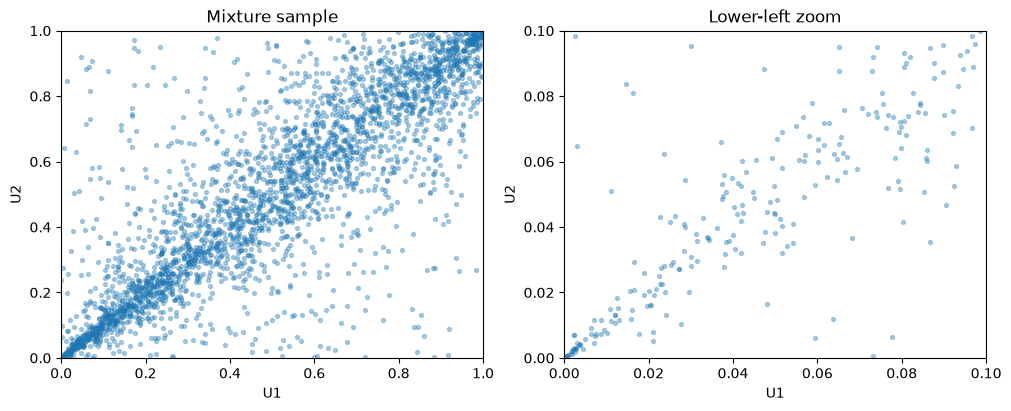

In [ ]:
components = [
  ("clayton", {"tau": 0.8}),
  ("student", {"tau": 0.8, "nu": 4}),
  ("gumbel", {"tau": 0.30}),
]
weights = [0.45, 0.35, 0.20]

n = 3000
seed = 7
u = sample_mixture(n, seed, components, weights)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

axes[0].scatter(u[:, 0], u[:, 1], s=8, alpha=0.35)
axes[0].set_title("Mixture sample")
axes[0].set_xlabel("U1")
axes[0].set_ylabel("U2")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

axes[1].scatter(u[:, 0], u[:, 1], s=8, alpha=0.35)
axes[1].set_title("Lower-left zoom")
axes[1].set_xlabel("U1")
axes[1].set_ylabel("U2")
axes[1].set_xlim(0, 0.1)
axes[1].set_ylim(0, 0.1)

plt.show()

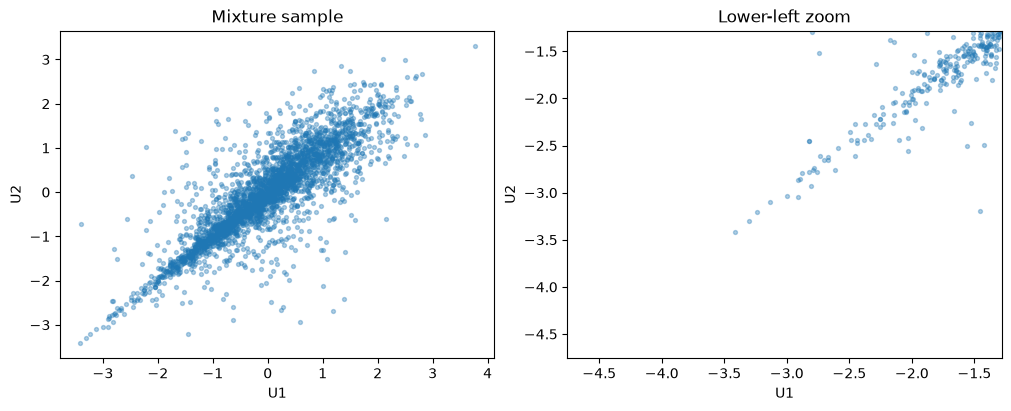

In [17]:
z_data = norm.ppf((u.clip(1e-6, 1 - 1e-6)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

axes[0].scatter(z_data[:, 0], z_data[:, 1], s=8, alpha=0.35)
axes[0].set_title("Mixture sample")
axes[0].set_xlabel("U1")
axes[0].set_ylabel("U2")

axes[1].scatter(z_data[:, 0], z_data[:, 1], s=8, alpha=0.35)
axes[1].set_title("Lower-left zoom")
axes[1].set_xlabel("U1")
axes[1].set_ylabel("U2")
axes[1].set_xlim(norm.ppf(1e-6), norm.ppf(0.1))
axes[1].set_ylim(norm.ppf(1e-6), norm.ppf(0.1))

plt.show()